## Import & Load

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

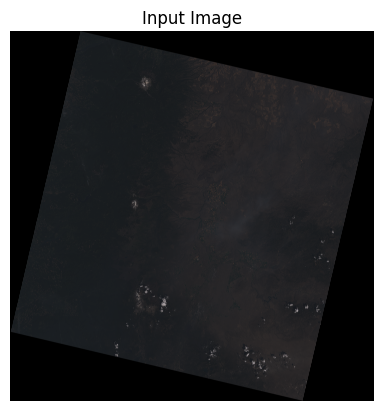

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load citra
img = cv2.imread('citra_input.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis('off')

## Konversi ke HSV

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

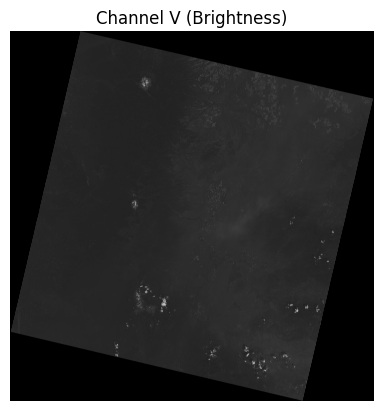

In [6]:
# Pisahkan komponen warna dan intensitas
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv_img)

plt.imshow(v, cmap='gray')
plt.title("Channel V (Brightness)")
plt.axis('off')

## Log Transform

In [7]:
# Persiapan untuk memisahkan illumination
v_float = np.float32(v) + 1.0
v_log = np.log(v_float)

## FFT

In [8]:
# Transformasi ke domain frekuensi (FFT)
dft = np.fft.fft2(v_log)
dft_shift = np.fft.fftshift(dft)

## Homomorphic Filter

In [9]:
# Membuat filter untuk memperbaiki pencahayaan (Homomorphic Filter)
M, N = v_log.shape

gammaH = 2.2
gammaL = 0.5
c = 1.0
D0 = min(M, N) / 12.0

u = np.arange(N)
v_arr = np.arange(M)
U, V_mesh = np.meshgrid(u, v_arr)

D = np.sqrt((U - N/2)**2 + (V_mesh - M/2)**2)
H = (gammaH - gammaL)*(1 - np.exp(-c*(D**2 / D0**2))) + gammaL

## Apply Filter & Inverse FFT

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

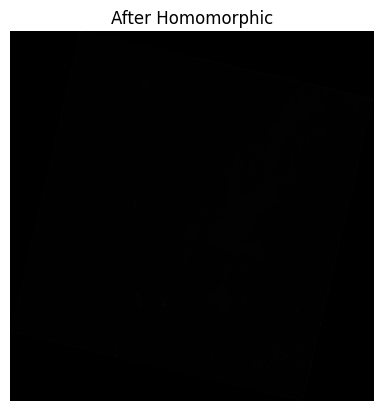

In [10]:
# Terapkan filter dan kembali ke domain spasial
filt = dft_shift * H
inv = np.fft.ifftshift(filt)
v_back = np.fft.ifft2(inv)
v_back = np.real(v_back)

v_exp = np.exp(v_back)

plt.imshow(v_exp, cmap='gray')
plt.title("After Homomorphic")
plt.axis('off')

## Clipping & Normalisasi

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

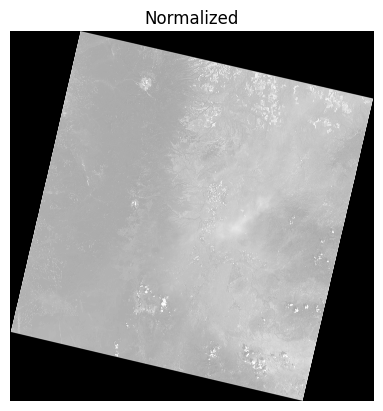

In [11]:
# Mengurangi efek outlier intensitas
p_low, p_high = np.percentile(v_exp, (2, 99))
v_clipped = np.clip(v_exp, p_low, p_high)

v_norm = cv2.normalize(v_clipped, None, 0, 255, cv2.NORM_MINMAX)
v_norm = np.uint8(v_norm)

plt.imshow(v_norm, cmap='gray')
plt.title("Normalized")
plt.axis('off')

## CLAHE

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

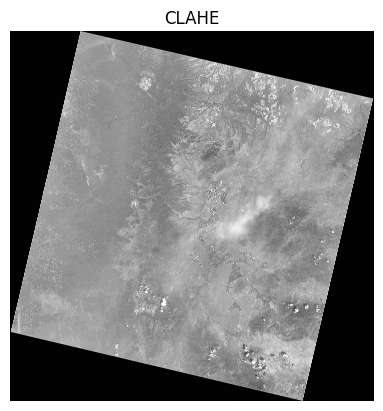

In [12]:
# Meningkatkan kontras lokal
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
v_clahe = clahe.apply(v_norm)

plt.imshow(v_clahe, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

## Gamma Correction

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

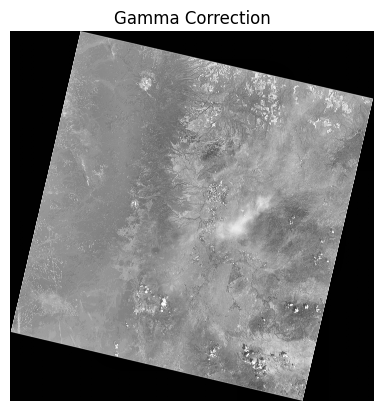

In [13]:
# Penyesuaian brightness halus
gamma = 1.1
v_final = np.power(v_clahe / 255.0, gamma) * 255
v_final = np.uint8(v_final)

plt.imshow(v_final, cmap='gray')
plt.title("Gamma Correction")
plt.axis('off')

## Saturation Enhancement

In [14]:
# Meningkatkan warna tanpa over-saturasi
s_norm = s / 255.0
s_enhanced = s * (1 + 0.8*(1 - s_norm))
s_enhanced = np.clip(s_enhanced, 0, 255).astype(np.uint8)

## Smoothing

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

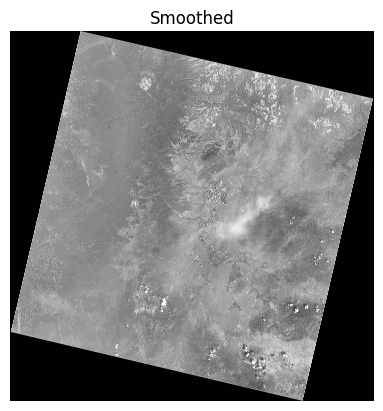

In [15]:
# Mengurangi noise tanpa merusak edge
v_final = cv2.bilateralFilter(v_final, 5, 50, 50)

plt.imshow(v_final, cmap='gray')
plt.title("Smoothed")
plt.axis('off')

## Reconstruct Image

(np.float64(-0.5), np.float64(7710.5), np.float64(7830.5), np.float64(-0.5))

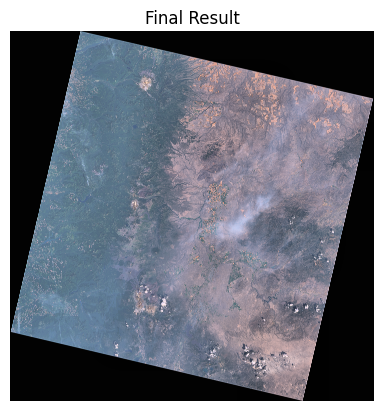

In [16]:
# Gabungkan kembali ke citra berwarna
hsv_out = cv2.merge((h, s_enhanced, v_final))
img_out = cv2.cvtColor(hsv_out, cv2.COLOR_HSV2RGB)

plt.imshow(img_out)
plt.title("Final Result")
plt.axis('off')

## Save Output

In [17]:
# Simpan hasil akhir
cv2.imwrite('improved_result.jpg', cv2.cvtColor(img_out, cv2.COLOR_RGB2BGR))

True